In [1]:
# Notebook setup
%load_ext autoreload
%autoreload 2
import os
import sys
nb_dir = os.path.split(os.getcwd())[0]
if nb_dir not in sys.path:
    sys.path.append(nb_dir)

### Load sample data (EEG 64 channels 10-10 system)

In [3]:
import mne
from mne.io import concatenate_raws, read_raw_edf
from mne.datasets import eegbci
from typing import cast

subjects = [1]  # may vary
runs = [4, 8, 12]  # may vary
raw_fnames = eegbci.load_data(subjects, runs)
raws = [read_raw_edf(f, preload=True) for f in raw_fnames]
# concatenate runs from subject
raw = concatenate_raws(raws)
# make channel names follow standard conventions
eegbci.standardize(raw)

Extracting EDF parameters from /home/carlos/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R04.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from /home/carlos/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R08.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Extracting EDF parameters from /home/carlos/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S001/S001R12.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...


In [4]:
from cerebra_atlas_python import CerebrA

cerebra = CerebrA(tex=False)  # Tex and noisecov plot interfere

# Montage should be in cerebra_mne/downsampled_montages.py (check examples/including_a_new_montage.ipynb)
cerebra.montage_name = "standard_1020-downsample-64-10-10"
cerebra.head_size = 0.10

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


Computing rank from covariance with rank=None
    Using tolerance 1.8e-11 (2.2e-16 eps * 64 dim * 1.2e+03  max singular value)
    Estimated rank (eeg): 64
    EEG: rank 64 computed from 64 data channels with 0 projectors


/home/carlos/Carlos/cerebra_atlas_python/cerebra_atlas_python/data/_cache.py:93: RuntimeWarning: This filename (/home/carlos/.cache/cerebra_atlas_python/cerebra/standard_1020-downsample-64-10-10_0.1_src_space_3mm_bem_0.33_0.0042_0.33_ico_4-fwd_5a97d1c4e5d46962136d47f1dd272f3850456112000c5770da6975671b0dd989.fif) does not conform to MNE naming conventions. All forward files should end with -fwd.fif, -fwd.fif.gz, _fwd.fif, _fwd.fif.gz, -fwd.h5 or _fwd.h5
  fwd = mne.read_forward_solution(path, verbose=False)


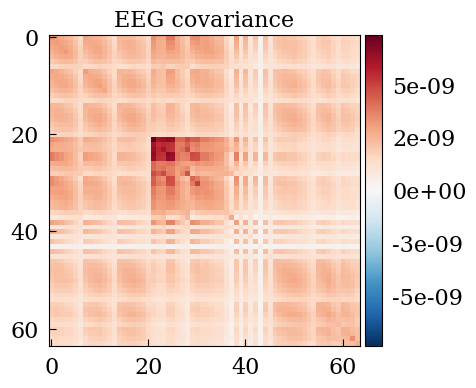

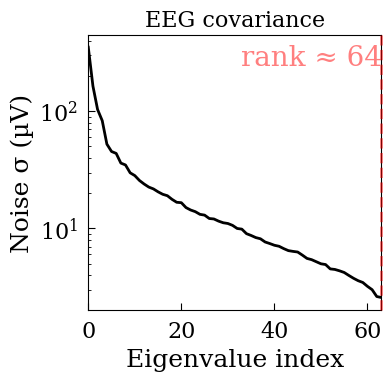

(<Figure size 380x370 with 2 Axes>, <Figure size 380x370 with 1 Axes>)

In [5]:
raw = cast(mne.io.Raw, raw)
fwd = cerebra.get_forward()
fwd["info"] = raw.info
noise_cov = mne.compute_raw_covariance(raw, verbose=False)
noise_cov.plot(raw.info)

In [6]:
inverse = mne.minimum_norm.make_inverse_operator(
    raw.info,
    fwd,
    noise_cov,
)

Computing inverse operator with 64 channels.
    64 out of 64 channels remain after picking


Selected 64 channels
Creating the depth weighting matrix...
    64 EEG channels
    limit = 31554/31553 = 3.874543
    scale = 58243 exp = 0.8
Whitening the forward solution.
Computing rank from covariance with rank=None
    Using tolerance 1.8e-11 (2.2e-16 eps * 64 dim * 1.2e+03  max singular value)
    Estimated rank (eeg): 64
    EEG: rank 64 computed from 64 data channels with 0 projectors
    Setting small EEG eigenvalues to zero (without PCA)
Creating the source covariance matrix
Adjusting source covariance matrix.
Computing SVD of whitened and weighted lead field matrix.


/tmp/ipykernel_28255/705171386.py:1: RuntimeWarning: No average EEG reference present in info["projs"], covariance may be adversely affected. Consider recomputing covariance using with an average eeg reference projector added.
  inverse = mne.minimum_norm.make_inverse_operator(
/tmp/ipykernel_28255/705171386.py:1: RuntimeWarning: No average EEG reference present in info["projs"], covariance may be adversely affected. Consider recomputing covariance using with an average eeg reference projector added.
  inverse = mne.minimum_norm.make_inverse_operator(


    largest singular value = 3.34916
    scaling factor to adjust the trace = 8.53145e+18 (nchan = 64 nzero = 0)


In [7]:
raw.set_eeg_reference("average", projection=True)

EEG channel type selected for re-referencing
Adding average EEG reference projection.
1 projection items deactivated
Average reference projection was added, but has not been applied yet. Use the apply_proj method to apply it.


<RawEDF | S001R04.edf, 64 x 60000 (375.0 s), ~29.4 MiB, data loaded>

In [8]:
raw.crop(0, 10)

<RawEDF | S001R04.edf, 64 x 1601 (10.0 s), ~868 KiB, data loaded>

In [9]:
import numpy as np


#! Signals are assumed to be zero mean
def getSNRNoBaseline(signal):
    # assert np.allclose(signal.mean(), 0), "signal should be zero mean"
    signal = np.power(signal, 2)
    m = np.mean(signal)  # squard power signal
    var = np.var(signal)  # variance of signal
    snr = np.where(var == 0, 0, m / var)
    snr = 10 * np.log10(snr)
    return snr


snr = getSNRNoBaseline(raw.get_data())
lambda2 = 1.0 / snr**2
method = "eLORETA"
stc = mne.minimum_norm.apply_inverse_raw(
    raw,
    inverse,
    lambda2=lambda2,
    method=method,
)

Preparing the inverse operator for use...
    Scaled noise and source covariance from nave = 1 to nave = 1
    Created the regularized inverter
    The projection vectors do not apply to these channels.
    Created the whitener using a noise covariance matrix with rank 64 (0 small eigenvalues omitted)
    Computing optimized source covariance (eLORETA)...
        Using independent orientation weights
        Fitting up to 20 iterations (this make take a while)...
        Converged on iteration 14 (5.1e-07 < 1e-06)
        Updating inverse with weighted eigen leads
[done]
Applying inverse to raw...
    Picked 64 channels from the data
    Computing inverse...
    Eigenleads already weighted ... 
    combining the current components...
[done]


In [14]:
stc.data.max(), stc.data.min()

(np.float64(4.080017095670847e-09), np.float64(3.2909262496620133e-13))

In [15]:
stc.data.shape

(31553, 1601)

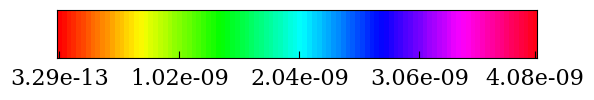

In [ ]:
from cerebra_atlas_python.plotting.colors import apply_colormap

colors = apply_colormap(stc.data, "hsv")
cerebra.plot_3d(colors=colors, update_interval=0.1)

In [33]:
stc.plot(cerebra.src_space)

ValueError: Source space must contain volume type, got discrete

In [ ]:
import mne

# mne.viz.plot_sparse_source_estimates(cerebra.src_space,stc, subject="icbm152", subjects_dir=cerebra.subjects_dir)
mne.viz.plot_sparse_source_estimates(cerebra.src_space, a)

IndexError: list index out of range